In [1]:
import VMBQC_functions
from VMBQC_functions import *

In [2]:
torch.cuda.is_available()

True

In [1]:
# Hyperparameters for the learning model

samples=8000 # Total number of samples 

qubits=7

depth=4

layers=depth

##  Learning models

In [4]:


dev = qml.device("default.mixed", wires=qubits,shots=target_samples)

@qml.qnode(dev)
def target_emodel(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas
    
    # Design of the fully corrected CQCA
    
    [qml.Hadamard(wires=q) for q in range(qubits)]
    

    for l in range(depth): 
        
        
        for q in range(qubits):
            qml.RZ(t[qubits*l+q],wires=q)
            
       
            
        
        for q in range(qubits):
            if q<qubits-1:
                qml.CZ(wires=[q,q+1])
        qml.CZ(wires=[0,qubits-1])  

        for q in range(qubits):
            qml.Hadamard(wires=q)

            qml.BitFlip((1-sigmoid(p[qubits*l+q]))/2,wires=q)
    
    return qml.sample()#qml.probs(wires=range(qubits))


# Here we build the fully corrected CQCA circuit which gives a pure state. 

dev = qml.device("default.qubit", wires=qubits,shots=samples)

@qml.qnode(dev)
def eqv_circ_st(params):  
    
    p=params[:int(len(params)/2)] # probabilities
    
    t=params[len(p):] # thetas
    
    # Design of the fully corrected CQCA
    
    [qml.Hadamard(wires=q) for q in range(qubits)]
    

    for l in range(depth): 
        
        
        for q in range(qubits):
            qml.RZ(t[qubits*l+q],wires=q)
            
       
            
        
        for q in range(qubits):
            if q<qubits-1:
                qml.CZ(wires=[q,q+1])
        qml.CZ(wires=[0,qubits-1])  

        for q in range(qubits):
            qml.Hadamard(wires=q)

    
    return qml.sample()#qml.probs(wires=range(qubits))

In [5]:
# Similar to the above cell we initialize our main model \tilde{\epsilon}_c with the hyperparameters
model=VMBQC(qubits,layers,N)


In [6]:
def sample_circ(par):
    
    binary_array = np.array(eqv_circ_st(par))
    # binary_array = np.array(target_emodel(par))
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list

# def sample_circ_target_emodel(par):
    
#     binary_array = np.array(target_emodel(par))
#     #print(binary_array)
#     powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
#     decimal_array = np.sum(binary_array * powers_of_two, axis=1)
#     decimal_list = decimal_array.tolist()
    
#     return decimal_list


#####   For model 2

'''
Activate the below part when model \tilde{\epsilon}_c is in action and comment the part above to avoid any overlap and do the reverse if needed.
'''
# # function to get a single (1) (or, N = shots) number of data sample(s) from a single run of CQCA with given correction probabilities (p)
def get_samples_jl(runs, params):
    arr=[]
    p=params[:qubits*depth] #np.repeat(params[:1],qubits*depth) # cause you only have one probability parameter

    t=params[len(p):] 
    
    arr.append(model.corrected_machine_f2(p,t))
    return np.concatenate(arr)


# # function to get m (e.g. "runs=20000/10=2000") number of data samples from our model
# def sample_circ(par):
    
#     # usinf joblib to parallalize the process of generating sufficient samples
#     results = Parallel(n_jobs = 20)(delayed(get_samples_jl)(r, par) for r in range(runs))
#     s_a=list(itertools.chain.from_iterable(results))
#     binary_array = np.array(s_a)
#     #print(binary_array)
#     powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
#     decimal_array = np.sum(binary_array * powers_of_two, axis=1)
#     decimal_list = decimal_array.tolist()
    
#     return decimal_list

def sample_circ_target_emodel(par):
    
    # usinf joblib to parallalize the process of generating sufficient samples
    results = Parallel(n_jobs = 20)(delayed(get_samples_jl)(r, par) for r in range(runs))
    s_a=list(itertools.chain.from_iterable(results))
    binary_array = np.array(s_a)
    #print(binary_array)
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list
    


# Testing the analytical result in vmbqc paper

Keep the $\theta$s fixed and see the effect of the $p_c$s

In [7]:
t2=np.array([0.25346914, 0.87569937, 0.45982243, 0.2101851 , 0.86541588,
        0.41781881, 0.75031244, 0.54803307, 0.38187175, 0.80987642,
        0.58446993, 0.3905621 , 0.10959787, 0.89544531, 0.03546959,
        0.86318735, 0.35996152, 0.63933876, 0.92219972, 0.15170662,
        0.56695048, 0.76443286, 0.75758383, 0.52563191, 0.62473946,
        0.75752699, 0.84102764, 0.7618131 ])
#np.random.uniform(0,1,qubits*depth)

In [8]:
t2

tensor([0.25346914, 0.87569937, 0.45982243, 0.2101851 , 0.86541588,
        0.41781881, 0.75031244, 0.54803307, 0.38187175, 0.80987642,
        0.58446993, 0.3905621 , 0.10959787, 0.89544531, 0.03546959,
        0.86318735, 0.35996152, 0.63933876, 0.92219972, 0.15170662,
        0.56695048, 0.76443286, 0.75758383, 0.52563191, 0.62473946,
        0.75752699, 0.84102764, 0.7618131 ], requires_grad=True)

In [9]:
# init_test_p = np.loadtxt(f'new_models/target_param_1_p_pos:{k}')
# init_test_p


k=[3+qubits*2] #range(qubits)
p2=np.ones((qubits*depth))
p2[k]=0.13540049 #np.random.uniform(.1,.5,len(k))
p2

tensor([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 0.13540049, 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        ], requires_grad=True)

In [10]:
k

[17]

/home/arun/.local/lib/python3.10/site-packages/pennylane/numpy/tensor.py:155: RuntimeWarning: divide by zero encountered in divide
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)


7.13610053062439 sec


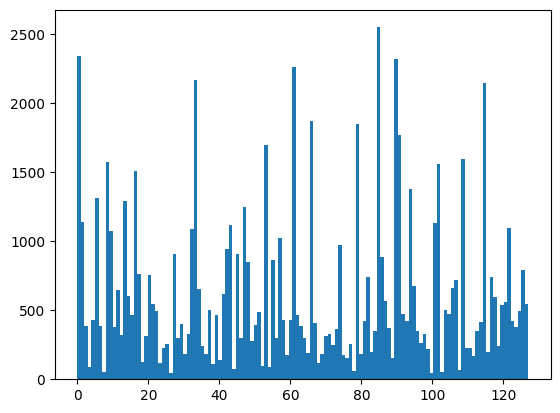

In [11]:
# def target_circuit(init_para):  
    
#     return sample_circ_target_emodel(init_para)



def target_circuit(init_para):  
    
    results = Parallel(n_jobs = 30)(delayed(get_samples_jl)(r, init_para) for r in range(target_samples))
    s_a=list(itertools.chain.from_iterable(results))
    binary_array = np.array(s_a)
    #print(binary_array)
    powers_of_two = 2 ** np.arange(binary_array.shape[1])[::-1]
    decimal_array = np.sum(binary_array * powers_of_two, axis=1)
    decimal_list = decimal_array.tolist()
    
    return decimal_list


init_para= np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)
s=time.time()
f_s_t=plt.hist(target_circuit(init_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')


In [12]:
(init_para)

tensor([        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf, -1.85402943,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,  0.25346914,  0.87569937,
         0.45982243,  0.2101851 ,  0.86541588,  0.41781881,  0.75031244,
         0.54803307,  0.38187175,  0.80987642,  0.58446993,  0.3905621 ,
         0.10959787,  0.89544531,  0.03546959,  0.86318735,  0.35996152,
         0.63933876,  0.92219972,  0.15170662,  0.56695048,  0.76443286,
         0.75758383,  0.52563191,  0.62473946,  0.75752699,  0.84102764,
         0.7618131 ], requires_grad=True)

In [13]:
np.savetxt(f'target_param_p_pos:{k}',init_para)
# init_test_p = np.loadtxt(f'new_models/target_param_p_pos:{k}')
# sigmoid(init_test_p[:qubits*depth])

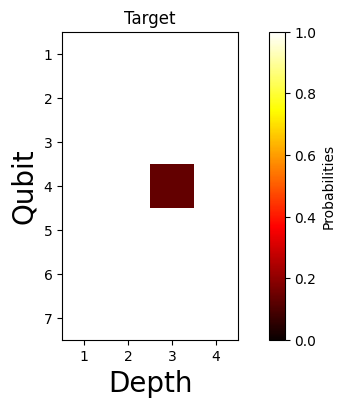

In [14]:
gen_prob_par(sigmoid(init_para[:qubits*depth]),qubits,depth,'Target')

In [15]:
pg=f_s_t[0]/(N*target_samples)
sum(pg)

1.0000000000000004

In [16]:
np.savetxt(f'target_dist_channel_k:{k}',pg)

In [17]:
# k=[3]
# np.savetxt(f'target_dist_qubit:{k}',pg)

In [18]:
# sampling from target distribution e.g. mixed gaussian
def sample_target_function():
    x=range(2**qubits)
    ret = np.random.choice(x,samples,p=pg)
    return ret.copy()

0.07584047317504883 sec


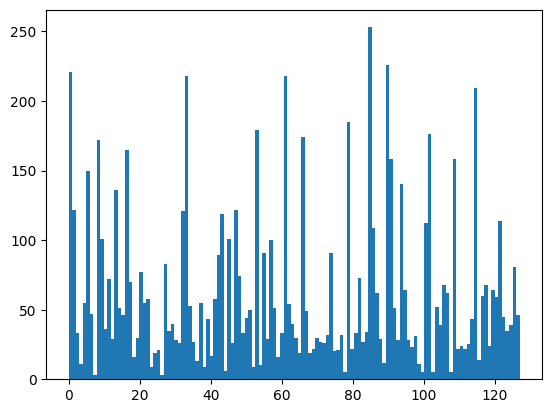

In [19]:
s=time.time()
opt_hist=plt.hist(sample_target_function(),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [20]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [21]:
# kernel function to calculate distance between two sample data points

def kernel_exp_torch(s1,s2):
    s1t = torch.tensor(s1, dtype = torch.float64).to(DEVICE)
    s2t = torch.tensor(s2, dtype = torch.float64).to(DEVICE)
    d1 = s1t.size(-1)
    d2 = s2t.size(-1)
    s1t = s1t.reshape([1,-1,1])
    s2t = s2t.reshape([1,-1,1])
    
    diffsquared = (torch.cdist(s1t,s2t,p=2.0).to(DEVICE))**2

    sigma_list=[0.5,4]
    exp = 0.0
    for sigma in sigma_list:
        expMatrix = torch.exp(diffsquared/(-2.0*sigma)).to(DEVICE)
        expMatrix = expMatrix/(len(sigma_list)*d1*d2)
        exp = exp + torch.sum(expMatrix).to(DEVICE)
        
    return exp

In [22]:
def mmd_loss(params):
    
    s2=sample_target_function()
    s1=sample_circ(params)
    res=kernel_exp_torch(s1,s1)-2*kernel_exp_torch(s1,s2)+kernel_exp_torch(s2,s2)
    return res.detach().cpu().numpy()


In [23]:
torch.repeat_interleave(torch.zeros(1),10)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [24]:
# Gradient for correction probabilities stated in eq. 17 of: https://arxiv.org/pdf/2310.13524.pdf

def mmd_grad_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    grad = torch.zeros(len(p)).to(DEVICE)
    
    
    
    sample_targ=sample_target_function()
    
    for i in range(len(p)):
        
        sample_y = sample_circ(params) ###############  eqv_circ_st(params)
        
        a=p[i].copy()
        inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
        
        p[i]=torch.tensor(100.0).numpy()
        
        sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
       
        
        p[i]=torch.tensor(-100.0).numpy()
        
        sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
        
        
        grad[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
        grad[i]= grad[i]*inner_derivative
        p[i]=a
        #if i == 0:
        #    print(params[:int(len(params)/2)])

        
    return grad


def mmd_grad_1layer_p_new(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    # grad = torch.zeros(len(p)).to(DEVICE)
    grad_1 = torch.zeros(len(p)).to(DEVICE)

    
    d=1
    for pr,i in zip(p,range(qubits*d)): # as you have only N prob that repeats across the first layer

        if pr!=torch.inf:
            
            sample_targ=sample_target_function()
            sample_y = sample_circ(params) ###############  eqv_circ_st(params)
            
            a=p[i].copy()
            inner_derivative = (sigmoid(torch.tensor(a))**2)*torch.exp(-torch.tensor(a))
            
            p[i]=torch.tensor(100.0).numpy()
            
            sample_x_1 = sample_circ(params) ###############  eqv_circ_st(params)
           
            
            p[i]=torch.tensor(-100.0).numpy()
            
            sample_x_0 = sample_circ(params) ###############  eqv_circ_st(params)
            
            
            grad_1[i]=2*(kernel_exp_torch(sample_y,sample_x_1)-kernel_exp_torch(sample_y,sample_x_0)) - 2*(kernel_exp_torch(sample_targ,sample_x_1)-kernel_exp_torch(sample_targ,sample_x_0))
            grad_1[i]= grad_1[i]*inner_derivative
            p[i]=a
        #if i == 0:
        #    print(params[:int(len(params)/2)])
        
    # grad_1=torch.concatenate([grad_1,torch.zeros(depth*(qubits-d)).to(DEVICE)])

        
    return grad_1
    
    
# Gradient for variational parameters \thetas stated in eq. 16 of: https://arxiv.org/pdf/2310.13524.pdf
    
def mmd_grad_theta(params):
    p=params[:qubits*depth]
    thetas=params[len(p):]
    prob = sample_circ(params)
    grad = torch.zeros(len(thetas)).to(DEVICE)
    
    for i in range(len(thetas)):
        # pi/2 phase
        thetas[i] += np.pi/2.
        prob_pos = sample_circ(params) # p_{theta}^{+}
        # -pi/2 phase
        thetas[i] -= np.pi
        prob_neg = sample_circ(params) # p_{theta}^{-}
        
        t1=kernel_exp_torch(prob, prob_pos)
        
        t2=kernel_exp_torch(prob, prob_neg)

        t3=kernel_exp_torch(sample_target_function(), prob_pos)
        
        t4=kernel_exp_torch(sample_target_function(), prob_neg)

        
        grad_pos = t1 - t2
        grad_neg = t3 - t4
        grad[i] = (grad_pos - grad_neg).detach().cpu()
        
        thetas[i] += np.pi/2.0 #reset to original value
        
    return grad


# combined gradient of both sets of parameters

def mmd_grad(params):
    #probs=params[:int(len(params)/2)]
    #thetas=params[len(probs):]
    grad=torch.cat((mmd_grad_1layer_p_new(params),mmd_grad_theta(params)))
    return grad

In [25]:
'''
import torch
import gc
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
            print(obj.shape, type(obj), obj.size(), obj.device)
    except:
        pass
'''

"\nimport torch\nimport gc\nfor obj in gc.get_objects():\n    try:\n        if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):\n            print(obj.shape, type(obj), obj.size(), obj.device)\n    except:\n        pass\n"

In [26]:
#torch.cuda.empty_cache()

In [27]:
#import gc

#gc.collect()
#torch.cuda.empty_cache()


In [28]:
# algorithm for gradient descent copied from : https://docs.pennylane.ai/en/stable/code/api/pennylane.GradientDescentOptimizer.html

# We rewrote the algorithm with our approximate gradient calculated from samples instead of using the in-built exact gradient 

class GradientDescentOptimizer_mmd_2:  
    def __init__(self, stepsize): # if some value is given here itself then it will become a by default value
        self.stepsize = stepsize

    def step_and_cost(self, objective_fn, *args, grad_fn=None, **kwargs):
        
        g, forward = self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, args)

        if forward is None:
            forward = objective_fn(*args, **kwargs)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0], forward
        return new_args, forward


    def step(self, objective_fn, *args, train, grad_fn=None, **kwargs):
        
        p_len=int(len(args[0])/2)
        if train=='p':
            arg1=args[0][:int(len(args[0])/2)]
        else:
            arg1=args[0][int(len(args[0])/2):]
        
        g= self.compute_grad(objective_fn, args, kwargs, grad_fn=grad_fn)
        new_args = self.apply_grad(g, arg1,args,train)

        # unwrap from list if one argument, cleaner return
        if len(new_args) == 1:
            return new_args[0]

        return new_args

    @staticmethod
    def compute_grad(objective_fn, args, kwargs, grad_fn=None):
       
        
        grad = mmd_grad(*args).detach().cpu().numpy()
        

        num_trainable_args = sum(getattr(arg, "requires_grad", False) for arg in args)
        grad = (grad,) if num_trainable_args == 1 else grad
        #print('grads--',grad[0])
        return grad


    def apply_grad(self, grad, arg1,args,train):
        
        #print('arg1--',arg1)#################
        args_new = list(arg1)
        
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):

                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
        else:
            trained_index = p_len ########## need to be generalized
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    args_new[index] = arg - self.stepsize * grad[0][trained_index]

                    trained_index += 1
            
        
        #print('new args-->',args_new[0])#############
        
        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new]) # here we can do this only because the they have same size
        

In [29]:
# We use parts the above above algorithm to finally use the Adagrad optimization algorithm below to update our tunable parameters

from pennylane.numpy import sqrt
class AdagradOptimizer_mmd_2(GradientDescentOptimizer_mmd_2):
    

    def __init__(self, stepsize=0.01, eps=1e-8):
        super().__init__(stepsize)
        self.eps = eps
        self.accumulation = None

    def apply_grad(self, grad, arg1, args, train):
        
        p_len=int(len(args[0])/2)
        args_new = list(arg1)

        if self.accumulation is None:
            self.accumulation = [0.0] * len(arg1)
            
        if train=='p':

            trained_index = 0
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
                    
        else:
            
            trained_index = p_len # need to be generalized
            
            for index, arg in enumerate(arg1):
                if getattr(arg, "requires_grad", False):
                    

                    self._update_accumulation(index, grad[0][trained_index])

                    coeff = self.stepsize / sqrt(self.accumulation[index] + self.eps)
                    args_new[index] = arg - coeff * grad[0][trained_index]

                    trained_index += 1
            
            

        if train=='p':
            return np.concatenate([args_new,args[0][len(args_new):]])
        else:
            return np.concatenate([args[0][:len(args_new)],args_new])


    def _update_accumulation(self, index, grad):
        
        self.accumulation[index] = self.accumulation[index] + grad**2

    def reset(self):
        
        self.accumulation = None

In [30]:
def cost(par):

    c=mmd_loss(par) 
    return c

In [31]:
cost(init_para)

array(0.00151692)

In [38]:
k

[17]

In [39]:
runs_2=10
iterations=199  # next time if run the same experiment for more agents then iterations=199


## seeding 
import random
import os

# Set seed for reproducibility (before any random ops)
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
####### end of seeding


cost_arr=[]
params_arr=[]
for r in range(runs_2):
    # opt1 = AdagradOptimizer_mmd_2(stepsize=0.2)
    opt2 = AdagradOptimizer_mmd_2(stepsize=0.1)
    
   
    
    p2=np.ones((qubits*depth))
    # p2[k]=np.random.uniform(.89,.95,len(k))
    t2=np.random.uniform(0,1,qubits*depth)
    init_p=np.concatenate([inv_sigmoid(p2),t2], requires_grad=True)

    params=init_p
    
    cost_arr.append(cost(init_p))
    params_arr.append(init_p)
    

    current_cost=[]
    
    for i in range(iterations):


        start=time.time()
        # params = opt1.step(cost, params,train='p')
        params = opt2.step(cost, params,train='t')
        end=time.time()
        current_cost.append(cost(params))
        cost_arr.append(current_cost[i])
        

        params_arr.append(params)
        #params_arr_tot_2.append(params)

        if i % 1 == 0:
            print(f"Cost at step {i}:", current_cost[i],f'of run:{r}')

            
            print('time taken-->',(end-start)/60,'min')

    
    np.savetxt(f'{k}_qubit_target_unit_learningmodel_depth:{depth}_loss_{r}.txt', cost_arr)
    np.savetxt(f'{k}_qubit_target_unit_learningmodel_depth:{depth}_par_{r}.txt', params_arr)


Cost at step 0: 0.006734696106452366 of run:0
time taken--> 0.09079622824986776 min
Cost at step 1: 0.005898209079123799 of run:0
time taken--> 0.09045012791951497 min
Cost at step 2: 0.005382981213307533 of run:0
time taken--> 0.09137242635091146 min
Cost at step 3: 0.005005123911285686 of run:0
time taken--> 0.09104365905125936 min
Cost at step 4: 0.0051617035749558435 of run:0
time taken--> 0.09068193833033243 min
Cost at step 5: 0.004609977043008952 of run:0
time taken--> 0.09099867741266886 min
Cost at step 6: 0.004145526040526586 of run:0
time taken--> 0.08925716876983643 min
Cost at step 7: 0.004081374631721611 of run:0
time taken--> 0.09031140406926473 min
Cost at step 8: 0.004184841970781165 of run:0
time taken--> 0.0905816634496053 min
Cost at step 9: 0.004020364296491635 of run:0
time taken--> 0.09086241722106933 min
Cost at step 10: 0.003231572493509364 of run:0
time taken--> 0.09214895566304525 min
Cost at step 11: 0.0030335043013312545 of run:0
time taken--> 0.09025315443

In [40]:
c_t = np.loadtxt(f'{k}_qubit_target_unit_learningmodel_depth:{depth}_loss_{9}.txt')
c_t.min()

tensor(0.00018592, requires_grad=True)

In [223]:
init_para

tensor([        inf,         inf,         inf, -1.51537929,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,  0.37454012,  0.95071431,
         0.73199394,  0.59865848,  0.15601864,  0.15599452,  0.05808361,
         0.86617615,  0.60111501,  0.70807258,  0.02058449,  0.96990985,
         0.83244264,  0.21233911,  0.18182497,  0.18340451,  0.30424224,
         0.52475643,  0.43194502,  0.29122914,  0.61185289,  0.13949386,
         0.29214465,  0.36636184,  0.45606998,  0.78517596,  0.19967378,
         0.51423444], requires_grad=True)

In [235]:
sigmoid(-1.51537929)

0.18014295050503126

In [221]:
cost_arr.index(min(cost_arr))

1497

In [224]:
opt_p=(params_arr[cost_arr.index(min(cost_arr))])
opt_p

tensor([       inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf, 0.41043698, 1.19323198,
        0.4719778 , 0.21179684, 0.24888134, 0.3346625 , 0.15308643,
        0.62616949, 0.44979806, 1.00411547, 0.33727742, 1.16711395,
        0.57124307, 0.45941024, 0.12771878, 0.85397231, 0.43093883,
        0.31507237, 0.31932199, 0.35847714, 0.49861533, 0.08417051,
        0.34963947, 0.4276187 , 0.38157226, 0.36386174, 0.25354522,
        0.82000511], requires_grad=True)

0.06687593460083008 sec


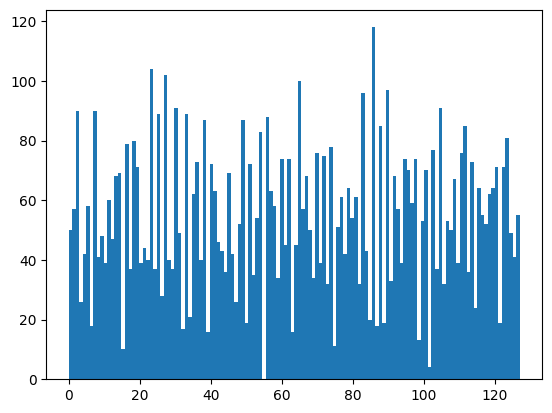

In [99]:
s=time.time()
f_s_t=plt.hist(sample_circ(opt_p),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [257]:
k=[3]#[1,3,5] #range(qubits)
c_t = np.loadtxt(f'{k}_qubit_target_unit_learningmodel_depth:{depth}_loss_{4}.txt')
c_t.min()

tensor(0.00075419, requires_grad=True)

In [258]:
u_t = np.loadtxt(f'unit_target_unit_learningmodel_depth:{depth}_loss_{4}.txt')
u_t.min()

tensor(0.00021196, requires_grad=True)

In [99]:
torch.argmin(torch.tensor(c_t))

tensor(1325)

In [100]:
p_t=np.loadtxt(f'new_models/layerwise_learning/{qubits}_qubit_pt_target_{k}:k_emodel_learningmodel_depth:{depth}_par_{9}.txt')


In [101]:
opt_p=p_t[torch.argmin(torch.tensor(c_t))][:qubits*depth]

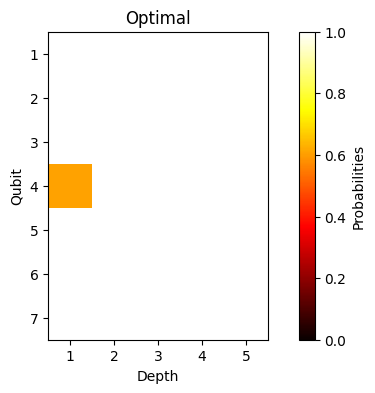

In [102]:
gen_prob_par(sigmoid(opt_p[:qubits*depth]),qubits,depth,'Optimal')

Make sure to set the P_c's =1 to make sure that the optimal loss is due to the correction 
probabilities and not just because of the thetas!

In [103]:
p_t[torch.argmin(torch.tensor(c_t))][k]=np.inf
p_t[torch.argmin(torch.tensor(c_t))]

tensor([       inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
               inf,        inf,        inf,        inf,        inf,
        5.2424539 , 2.53084567, 2.83766162, 4.0989831 , 3.41115291,
        0.57707982, 5.58965071, 4.42632885, 6.05592826, 5.34286107,
        5.92496177, 1.29479925, 3.70974807, 0.2568795 , 4.64353438,
        1.10400389, 3.07083355, 4.06724   , 2.04109691, 2.12745092,
        2.11478246, 5.0009409 , 2.71392932, 0.55010297, 6.94826504,
        4.83994466, 4.89938237, 3.45642205, 4.85661559, 4.40477933,
        1.67678926, 4.59794713, 1.31727081, 3.62116698, 3.28313281], requires_grad=True)

In [104]:
opt_p

tensor([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
        inf, inf, inf, inf, inf, inf, inf, inf, inf], requires_grad=True)

In [106]:
cost(p_t[torch.argmin(torch.tensor(c_t))])

array(0.00061433)

0.3290705680847168 sec


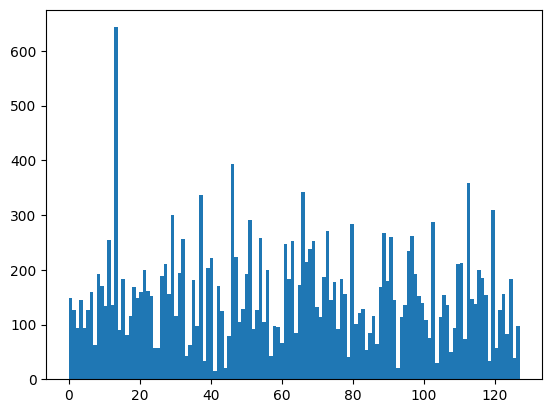

In [72]:
opt_para= p_t[torch.argmin(torch.tensor(c_t))]
s=time.time()
f_s_t=plt.hist(eqv_circ_st(opt_para),bins=2**qubits)
e=time.time()
print(e-s,'sec')

In [109]:
pg=f_s_t[0]/(target_samples) #f_s_t[0]/(N*target_samples)
(pg)

array([0.0074 , 0.00635, 0.0047 , 0.0072 , 0.00465, 0.0063 , 0.00795,
       0.0031 , 0.0096 , 0.00855, 0.0067 , 0.01275, 0.00675, 0.03215,
       0.0045 , 0.00915, 0.004  , 0.0058 , 0.0084 , 0.00745, 0.008  ,
       0.00995, 0.00805, 0.0076 , 0.0029 , 0.0029 , 0.0094 , 0.0105 ,
       0.00775, 0.01505, 0.0058 , 0.0097 , 0.0128 , 0.00215, 0.00315,
       0.0091 , 0.00485, 0.0168 , 0.0017 , 0.0102 , 0.01105, 0.00075,
       0.0085 , 0.0062 , 0.001  , 0.00395, 0.0197 , 0.0112 , 0.0052 ,
       0.00645, 0.00965, 0.01455, 0.0046 , 0.0063 , 0.0129 , 0.0052 ,
       0.01   , 0.0021 , 0.0049 , 0.0048 , 0.0033 , 0.0124 , 0.00915,
       0.01265, 0.00425, 0.00865, 0.0171 , 0.01075, 0.0119 , 0.01265,
       0.0066 , 0.00565, 0.00935, 0.0135 , 0.0072 , 0.0089 , 0.00455,
       0.0092 , 0.0078 , 0.002  , 0.01415, 0.00505, 0.00605, 0.00645,
       0.00265, 0.00425, 0.00575, 0.00325, 0.0084 , 0.01335, 0.00895,
       0.01295, 0.0072 , 0.001  , 0.0057 , 0.0068 , 0.0117 , 0.0131 ,
       0.00965, 0.00

In [107]:
np.savetxt(f'target_dist_opt_model_qubit_p_ind:{k}',pg)

Plots ideas:

Do not make the plot of comparision between etilde vs unitary learning; instead it should be
unitary vs unitary when in one scenario the target is generated from unitary and in the 
other case the target is generated using the same thetas but add to that we have $p_c$ which
makes the output dist. hardar for the unitary.

# For qubit-wise target model, put the byproducts on the middle qubit so that it has non trivial effect on all qubits when it reaches the last layer!

## Testing of the loss

In [73]:
c_t=np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_loss_{0}.txt')
c_t.min()

tensor(0.00059127, requires_grad=True)

In [20]:
p_t=np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt')
sigmoid(p_t[-1])

tensor([0.8449098 , 0.98696726, 0.93087352, 0.89801162, 0.79555444,
        0.79554912, 0.77416647, 0.96495418, 0.89860828, 0.92490551,
        0.76609255, 0.99202554, 0.95628839, 0.8080558 , 0.80126412,
        0.80161461, 0.82877979, 0.88021249, 0.85826446, 0.82582056,
        0.72444348, 0.38661631, 0.68023842, 0.55542909, 0.68506884,
        0.80186974, 0.64297915, 0.658578  , 0.70664503, 0.4845197 ,
        0.54616914, 0.34221669, 0.44806727, 0.79538243, 0.77070985,
        0.83995806, 0.655738  , 0.84648353, 0.6884188 , 0.78171101], requires_grad=True)

In [74]:
from matplotlib.animation import FuncAnimation, PillowWriter


def load_and_reshape(txt_file):
    arr = sigmoid(np.loadtxt(txt_file)[:, :qubits * depth])
    if arr.ndim != 2 or arr.shape[1] != depth*qubits:
        raise ValueError("Expected (n_frames, 56) shape")
    # Reshape to (frames, rows=7, cols=8) — which matches your arr.reshape(-1,7,8)
    return arr.reshape(-1, depth, qubits)

def animate_grid(frames, output=f'new_models/p_evol_plots/{k}_qubit_p_target_etilde_learningmodel.gif', fps=10, cmap='hot'):
    n_frames, rows, cols = frames.shape  # rows=7, cols=8
    fig, ax = plt.subplots()
    
    # Transpose the first frame for correct axes orientation
    im = ax.imshow(frames[0].T,
                   vmin=frames.min(), vmax=frames.max(),
                   cmap=cmap, aspect='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Probabilities')
    ax.set_title(f'Frame 1/{n_frames}')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Qubit')

    def update(i):
        im.set_data(frames[i].T)  # Transpose each frame before plotting
        ax.set_title(f'Evolution of probs at epoch {i+1}/{n_frames}')
        return (im,)

    anim = FuncAnimation(fig, update, frames=n_frames,
                         interval=1000/fps, blit=True)
    writer = PillowWriter(fps=fps)
    anim.save(output, writer=writer)
    plt.close(fig)
    print(f"✅ GIF saved as '{output}'")

if __name__ == "__main__":
    data3d = load_and_reshape(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt'
                             )
    animate_grid(data3d, fps=10)

✅ GIF saved as 'new_models/p_evol_plots/0_qubit_p_target_etilde_learningmodel.gif'


In [98]:
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_loss.txt', cost_arr)
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_par.txt', params_arr)

In [6]:
par_model = np.loadtxt(f'etilde_5q_etilde_all_same_p_target_par_{4}.txt')

In [55]:
sigmoid(params_arr[-1])

tensor([0.89734693, 0.99183773, 0.95576729, 0.93389926, 0.86195247,
        0.86194857, 0.84616755, 0.97786667, 0.93430133, 0.95183728,
        0.84013622, 0.99501522, 0.97230211, 0.87105183, 0.86611986,
        0.86637505, 0.88593433, 0.921818  , 0.90668497, 0.88382444,
        0.6708102 , 0.50987329, 0.59679844, 0.61452177, 0.63554228,
        0.70789352, 0.52490523, 0.64890594, 0.66650153, 0.48661639,
        0.66985786, 0.5176338 , 0.49126563, 0.74056075, 0.37632773,
        0.71267199, 0.59979526, 0.499436  , 0.68659142, 0.63182744], requires_grad=True)

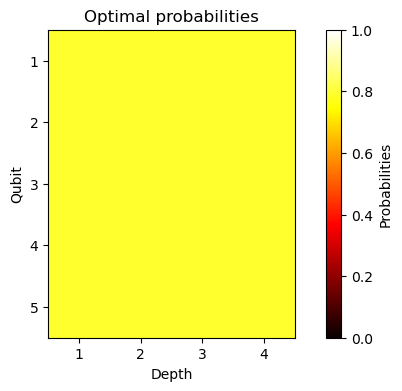

In [8]:
gen_prob_par(par_model[-1][:qubits*depth],qubits,depth)

In [785]:
cost_channel_target = np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_unit_learningmodel_loss_{4}.txt')
cost_channel_target.shape

(1000,)

In [799]:
cost_channel_target[:200]

tensor([0.05421503, 0.03850735, 0.02095143, 0.01489375, 0.00952386,
        0.00607734, 0.00429791, 0.005213  , 0.00419301, 0.00458129,
        0.00435567, 0.00365019, 0.00258474, 0.00350518, 0.0026983 ,
        0.00290786, 0.00336054, 0.00256478, 0.00207736, 0.00216366,
        0.00240381, 0.00286678, 0.00244549, 0.00198848, 0.00195944,
        0.00223772, 0.00177095, 0.00234615, 0.00207199, 0.00236809,
        0.00173223, 0.00174109, 0.00204599, 0.00149069, 0.00200329,
        0.00171619, 0.00195475, 0.00187765, 0.00203812, 0.00168964,
        0.00162466, 0.00178552, 0.00184245, 0.00217061, 0.00182756,
        0.00202922, 0.00168082, 0.00135248, 0.00186408, 0.00258813,
        0.00228841, 0.00175759, 0.00238944, 0.001282  , 0.00155067,
        0.00151754, 0.00193157, 0.00177404, 0.0017899 , 0.00121984,
        0.0018081 , 0.0020455 , 0.00202657, 0.00187043, 0.00151638,
        0.00153833, 0.00156621, 0.00237812, 0.00218911, 0.00127614,
        0.00207027, 0.00120094, 0.00137075, 0.00

In [794]:
cost_channel_target.min()

tensor(0.00066775, requires_grad=True)

In [795]:
cost_unit_target = np.loadtxt(f'new_models/qubitwise_target/unit_target_unit_learningmodel_loss_{4}.txt')
cost_unit_target.min()

tensor(0.00046734, requires_grad=True)

In [800]:
cost_unit_target[:200]

tensor([0.11200129, 0.07922287, 0.06322121, 0.04795331, 0.03363409,
        0.02371302, 0.01735112, 0.01285907, 0.00914898, 0.00534169,
        0.00430852, 0.00468036, 0.00283431, 0.0033728 , 0.00301447,
        0.00264991, 0.00275133, 0.00221101, 0.00158484, 0.00193348,
        0.00205514, 0.00310071, 0.00203717, 0.00195564, 0.00160935,
        0.00160951, 0.00108001, 0.00185753, 0.00215449, 0.00130635,
        0.00128562, 0.00121872, 0.00100867, 0.00185412, 0.00142701,
        0.00122438, 0.00167464, 0.00154832, 0.00145519, 0.00186811,
        0.00155284, 0.00146982, 0.00179954, 0.00216424, 0.00147452,
        0.00117127, 0.00135013, 0.0014096 , 0.00153836, 0.00146082,
        0.00140576, 0.00135788, 0.00100152, 0.00108709, 0.00122515,
        0.001154  , 0.00093558, 0.00103369, 0.00165848, 0.00106538,
        0.00190281, 0.00099547, 0.00109051, 0.00105161, 0.00097979,
        0.00134383, 0.0012657 , 0.00087991, 0.00090483, 0.00080105,
        0.00119594, 0.00134895, 0.00121688, 0.00

## Plotting loss

In [260]:
ave_cost=[]
std=[]
a=[]
total_cost_arr=[]


runs_2=5
iterations=299
for r in range(runs_2):
    total_cost_arr.append(c_t[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a=[]
    for i in range(runs_2):
        a.append(total_cost_arr[i][j])
    std.append(np.std(a))
    ave_cost.append(np.average(a))


    
ave_cost_1=[]
std_1=[]
a_1=[]
total_cost_arr_1=[]


runs_2=5
iterations=299
for r in range(runs_2):
    total_cost_arr_1.append(u_t[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a_1=[]
    for i in range(runs_2):
        a_1.append(total_cost_arr_1[i][j])
    std_1.append(np.std(a_1))
    ave_cost_1.append(np.average(a_1))



/tmp/ipykernel_3908721/997660169.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y, 'k', color='navy',label='Target:{\mathcal{E}}_c$')
/tmp/ipykernel_3908721/997660169.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y_1, 'k', color='#6CDB7A',label='Target:$U_c$')


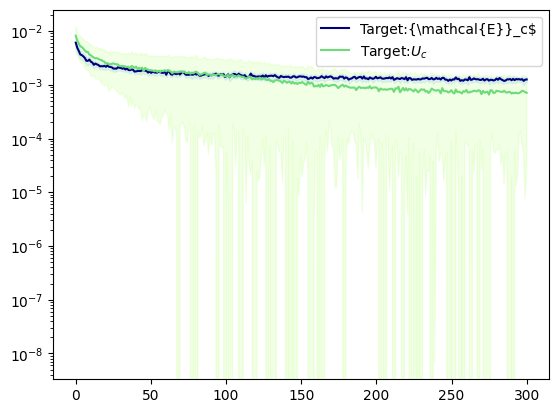

In [261]:
fig, ax = plt.subplots()
x=np.linspace(0,iterations+1,iterations+1)
y=ave_cost
yerr=std

y_1=ave_cost_1
yerr_1=std_1


ax.semilogy(x, y, 'k', color='navy',label='Target:{\mathcal{E}}_c$')
ax.fill_between(x, np.array(y)+np.array(yerr)/2,np.array(y)+(-1)*np.array(yerr)/2,
    alpha=0.1, edgecolor='dodgerblue', facecolor='dodgerblue')

ax.semilogy(x, y_1, 'k', color='#6CDB7A',label='Target:$U_c$')
ax.fill_between(x, np.array(y_1)+np.array(yerr_1),np.array(y_1)+(-1)*np.array(yerr_1),
    alpha=0.1, edgecolor='#7FFF00', facecolor='#7FFF00')
# plt.title(r'Target distribution: $\widetilde{\epsilon}_{c}(p=\sim0.7)$')
# plt.ylim(0.00000007,0.1)
plt.legend()
plt.show()

In [103]:
########## ******  The actual plot with 4 graphs of double gaussian is available in my desktop and not in gorka's workstation

In [272]:

import gc

mmd_grad(params).cpu()
del mmd_grad
gc.collect()
torch.cuda.empty_cache()
